In [1]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


In [13]:
# Load your trained ResNet50 model
model = models.resnet50(pretrained=False)
model.fc = torch.nn.Linear(model.fc.in_features, 4)  # Assuming 3 classes: Glioma, Meningioma, Pituitary
model.load_state_dict(torch.load('brain_tumor_model.pth', map_location='cpu'))
model.eval()

# Load and preprocess input image
image_path = '/home/tanuj/Brain_MRI/brain_tumor_mri_dataset/Testing/pituitary/image(7).jpg'
img = Image.open(image_path).convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

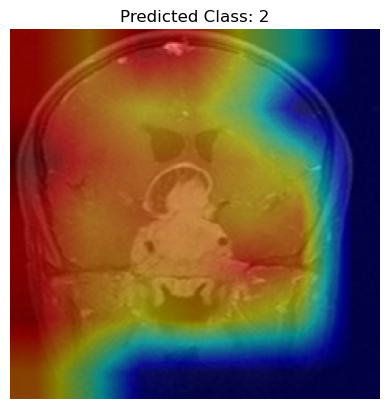

In [14]:
input_tensor = transform(img).unsqueeze(0)  # Shape: [1, 3, 224, 224]

# For Grad-CAM, we need normalized numpy image as well
rgb_img = np.array(img.resize((224, 224))) / 255.0
rgb_img = np.float32(rgb_img)

# Target layer (usually the last conv layer)
target_layer = model.layer4[-1]

# Create Grad-CAM object
cam = GradCAM(model=model, target_layers=[target_layer])

# Choose target class (optional): 0, 1, or 2
# You can use prediction or force a specific class
outputs = model(input_tensor)
predicted_class = outputs.argmax(dim=1).item()

# Generate CAM
grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(predicted_class)])
grayscale_cam = grayscale_cam[0]  # Remove batch dimension

# Overlay CAM on original image
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

# Save or display
plt.imshow(visualization)
plt.title(f"Predicted Class: {predicted_class}")
plt.axis('off')
plt.show()